# ♻️ EcoSort-Search — Entraînement du modèle (ResNet18 + PyTorch Lightning)

Ce notebook est prévu pour tourner **dans Kaggle Notebooks**, avec le dataset
*Garbage Classification* ajouté comme input (bouton **+ Add Data**, chercher
`garbage classification`, sélectionner le dataset qui contient les dossiers
`cardboard/`, `glass/`, `metal/`, `paper/`, `plastic/`, `trash/`).

**Avant de lancer :** *Settings* (panneau de droite) → **Accelerator : GPU T4 x2**.

Architecture inspirée du projet de référence `garbage_classifier`
(ResNet18 pré-entraîné + PyTorch Lightning), adaptée ici en cellules de
notebook plutôt qu'en package multi-fichiers pour rester autonome sur Kaggle.

Étapes :
1. Détection automatique du dossier du dataset
2. DataModule (chargement + augmentation de données)
3. LightningModule (ResNet18, transfer learning)
4. Entraînement (backbone gelé, puis fine-tuning)
5. Évaluation (matrice de confusion, rapport de classification)
6. Sauvegarde du checkpoint `.ckpt` à télécharger


In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torchmetrics
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix

print("PyTorch version :", torch.__version__)
print("PyTorch Lightning version :", pl.__version__)
print("GPU disponible :", torch.cuda.is_available())


PyTorch version : 2.13.0+cpu
PyTorch Lightning version : 2.6.5
GPU disponible : False


## 1. Détection automatique du dossier du dataset

Les datasets Kaggle sont montés sous `/kaggle/input/<nom-du-dataset>/...` et
la profondeur varie selon le dataset choisi. Le code cherche automatiquement
le dossier qui contient réellement les 6 classes attendues.

In [2]:
EXPECTED_CLASSES = {"cardboard", "glass", "metal", "paper", "plastic", "trash"}

def find_dataset_root(base_dir=r"C:\Users\hp\Downloads\archive\Garbage_Dataset_Classification\DATASET"):
    for root, dirs, files in os.walk(base_dir):
        subdirs = set(d.lower() for d in dirs)
        if EXPECTED_CLASSES.issubset(subdirs):
            return root
    return None

DATASET_DIR = find_dataset_root()
if DATASET_DIR is None:
    raise FileNotFoundError(
        "Dossier avec les 6 classes introuvable. Vérifiez que le dataset "
        "'Garbage Classification' a bien été ajouté via + Add Data, puis "
        "inspectez /kaggle/input manuellement avec `!find /kaggle/input -maxdepth 3`."
    )

print("Dataset trouvé :", DATASET_DIR)
for c in sorted(EXPECTED_CLASSES):
    n = len(glob.glob(os.path.join(DATASET_DIR, c, "*")))
    print(f"  - {c}: {n} images")


Dataset trouvé : C:\Users\hp\Downloads\archive\Garbage_Dataset_Classification\DATASET
  - cardboard: 2214 images
  - glass: 2500 images
  - metal: 2084 images
  - paper: 2315 images
  - plastic: 2288 images
  - trash: 2500 images


## 2. DataModule — chargement + augmentation

Deux instances distinctes d'`ImageFolder` (une par transform) partageant les
mêmes indices de split : c'est volontaire, un seul `ImageFolder` partagé
entre train/val ferait que changer son `.transform` affecterait les DEUX
splits (ils pointent vers le même objet sous-jacent).

In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42
TRAIN_RATIO = 0.8

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

full_train = datasets.ImageFolder(DATASET_DIR, transform=train_transform)
full_val = datasets.ImageFolder(DATASET_DIR, transform=val_transform)
CLASS_NAMES = full_train.classes
print("Ordre des classes (à reporter dans Model_Dl/utils/config.py) :", CLASS_NAMES)

n_total = len(full_train)
indices = list(range(n_total))
rng = np.random.default_rng(SEED)
rng.shuffle(indices)
n_train = int(TRAIN_RATIO * n_total)

train_dataset = Subset(full_train, indices[:n_train])
val_dataset = Subset(full_val, indices[n_train:])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train : {len(train_dataset)} images | Val : {len(val_dataset)} images")


Ordre des classes (à reporter dans Model_Dl/utils/config.py) : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Train : 11120 images | Val : 2781 images


## 3. LightningModule — ResNet18 (transfer learning)

Backbone ResNet18 pré-entraîné sur ImageNet, tête de classification
remplacée pour nos 6 classes. `fine_tune=False` gèle le backbone (phase 1),
`fine_tune=True` le dégèle (phase 2).

In [4]:
class GarbageClassifier(pl.LightningModule):
    def __init__(self, num_classes, learning_rate=1e-3, fine_tune=False):
        super().__init__()
        self.save_hyperparameters()

        self.model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        if not fine_tune:
            for param in self.model.parameters():
                param.requires_grad = False

        in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features, num_classes)

        self.criterion = nn.CrossEntropyLoss()
        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = torch.argmax(logits, dim=1)
        self.train_acc(preds, y)
        self.log("train_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log("train_acc", self.train_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = torch.argmax(logits, dim=1)
        self.val_acc(preds, y)
        self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log("val_acc", self.val_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)


NUM_CLASSES = len(CLASS_NAMES)
model = GarbageClassifier(num_classes=NUM_CLASSES, learning_rate=1e-3, fine_tune=False)
print(model)


GarbageClassifier(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e

## 4. Entraînement — Phase 1 (backbone gelé)

In [ ]:
checkpoint_cb_p1 = ModelCheckpoint(
    dirpath=r"C:\Users\hp\Downloads\EcoSort-Search\Model_Dl\models\weights", filename="phase1-{epoch}-{val_acc:.2f}",
    monitor="val_acc", mode="max", save_top_k=1,
)
early_stop_cb = EarlyStopping(monitor="val_loss", patience=4, mode="min")

trainer_phase1 = pl.Trainer(
    max_epochs=15,
    callbacks=[checkpoint_cb_p1, early_stop_cb],
    accelerator="auto",
    log_every_n_steps=10,
)
trainer_phase1.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

best_phase1_path = checkpoint_cb_p1.best_model_path
print("Meilleur checkpoint phase 1 :", best_phase1_path)


## 4bis. Entraînement — Phase 2 (fine-tuning)

On repart du meilleur checkpoint de la phase 1, on dégèle tout le backbone,
et on continue l'entraînement avec un learning rate plus faible.

In [ ]:
model_finetuned = GarbageClassifier.load_from_checkpoint(
    best_phase1_path, num_classes=NUM_CLASSES, learning_rate=1e-5, fine_tune=True
)
# S'assurer que tous les paramètres sont bien dégelés pour cette phase
for param in model_finetuned.model.parameters():
    param.requires_grad = True

checkpoint_cb_p2 = ModelCheckpoint(
    dirpath=r"C:\Users\hp\Downloads\EcoSort-Search\Model_Dl\models\weights", filename="model_resnet18_ecosort",
    monitor="val_acc", mode="max", save_top_k=1,
)
early_stop_cb_p2 = EarlyStopping(monitor="val_loss", patience=4, mode="min")

trainer_phase2 = pl.Trainer(
    max_epochs=10,
    callbacks=[checkpoint_cb_p2, early_stop_cb_p2],
    accelerator="auto",
    log_every_n_steps=10,
)
trainer_phase2.fit(model_finetuned, train_dataloaders=train_loader, val_dataloaders=val_loader)

best_final_path = checkpoint_cb_p2.best_model_path
print("Meilleur checkpoint final :", best_final_path)


## 5. Évaluation

In [5]:
best_final_path = r"models\weights\model_resnet18_ecosort.ckpt"
NUM_CLASSES = len(CLASS_NAMES)

In [6]:
import os
print(os.getcwd())
print(os.path.exists("models/weights/model_resnet18_ecosort.ckpt"))

c:\Users\hp\Downloads\EcoSort-Search\Model_Dl
True


              precision    recall  f1-score   support

   cardboard       0.94      0.89      0.91       442
       glass       0.93      0.93      0.93       520
       metal       0.83      0.96      0.89       395
       paper       0.93      0.91      0.92       476
     plastic       0.89      0.88      0.89       426
       trash       0.96      0.93      0.95       522

    accuracy                           0.92      2781
   macro avg       0.91      0.92      0.91      2781
weighted avg       0.92      0.92      0.92      2781



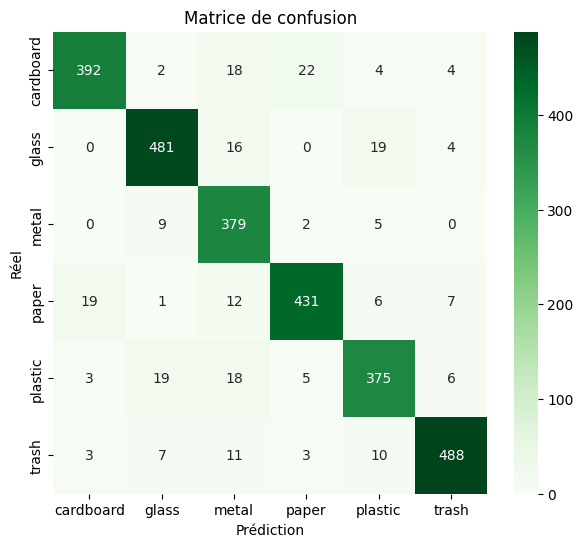

In [7]:
final_model = GarbageClassifier.load_from_checkpoint(best_final_path, num_classes=NUM_CLASSES)
final_model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for x, y in val_loader:
        logits = final_model(x)
        preds = torch.argmax(logits, dim=1)
        y_true.extend(y.tolist())
        y_pred.extend(preds.tolist())

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Prédiction"); plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()


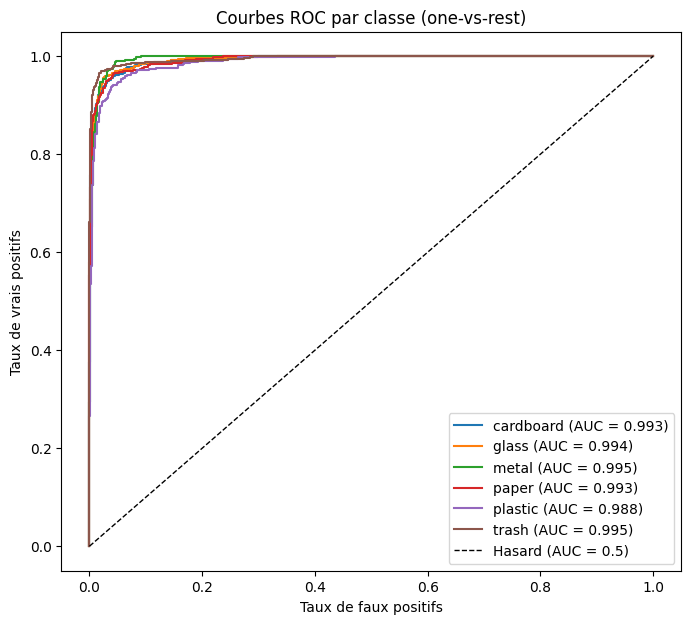

In [8]:
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# --- Récupération des probabilités (pas juste la classe prédite) ---
final_model.eval()
y_true, y_probs = [], []
with torch.no_grad():
    for x, y in val_loader:
        logits = final_model(x)
        probs = torch.softmax(logits, dim=1)
        y_probs.extend(probs.tolist())
        y_true.extend(y.tolist())

y_true = np.array(y_true)
y_probs = np.array(y_probs)
n_classes = len(CLASS_NAMES)

# --- Binarisation "one-vs-rest" : nécessaire pour tracer une courbe ROC ---
# par classe dans un problème multiclasse (la ROC est définie pour du binaire)
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

# --- Calcul d'une courbe ROC + AUC par classe ---
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# --- Tracé ---
plt.figure(figsize=(8, 7))
colors = plt.cm.tab10.colors
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i % 10],
              label=f"{CLASS_NAMES[i]} (AUC = {roc_auc[i]:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Hasard (AUC = 0.5)")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC par classe (one-vs-rest)")
plt.legend(loc="lower right")
plt.show()

## 6. Récapitulatif

Le checkpoint final est déjà sauvegardé dans `/kaggle/working/` grâce à
`ModelCheckpoint` (phase 2). Téléchargez-le depuis le panneau *Output* du
notebook, puis placez-le dans :

```
Model_Dl/models/weights/model_resnet18_ecosort.ckpt
```

⚠️ **Vérifiez `CLASS_NAMES` affiché plus haut** et reportez-le exactement
dans `CLASSES` de `Model_Dl/utils/config.py` ainsi que `RAW_CLASSES_ORDER`
dans `Model_Dl/model_utils.py` (l'ordre dépend de l'ordre alphabétique des
dossiers détecté par `ImageFolder`, qui peut différer légèrement du dataset).

In [ ]:
print("Checkpoint final :", r"C:\Users\hp\Downloads\EcoSort-Search\Model_Dl\models\weights\model_resnet18_ecosort.ckpt")
print("Classes (à reporter dans config.py et model_utils.py) :", CLASS_NAMES)
